<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad4/Practica_3_An%C3%A1lisis_de_Componentes_Principales_(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

In [22]:
prestamos = pd.read_csv("/content/lending_club_2007_2011_6_states (3).csv")
prestamos.head()


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


In [23]:
le = LabelEncoder()
prestamos["grade_code"] = le.fit_transform(prestamos["grade"])
prestamos["purpose_code"] = le.fit_transform(prestamos["purpose"])
prestamos["addr_state_code"] = le.fit_transform(prestamos["addr_state"])
prestamos["home_ownership_code"] = le.fit_transform(prestamos["home_ownership"])

In [24]:
model_columns = ['funded_amnt', "int_rate", "grade_code", 'purpose_code',
                 'addr_state_code',
                 'home_ownership_code', 'annual_inc', 'dti', 'revol_util',
                 'pub_rec_bankruptcies']
x=prestamos[model_columns]
x.head()
x = x.fillna(x.mean())

In [25]:
prestamos["repaid"] = (
    prestamos["loan_status"] == "Fully Paid"
).astype(int)
y = prestamos['repaid']
y.head()

,repaid
0,1
1,1
2,1
3,0
4,0


In [26]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[-1.20758742e+00,  1.04653339e+00,  2.87715255e-01, ...,
        -6.43599403e-01,  1.74122331e+00, -1.99965251e-01],
       [-1.48515809e-01,  3.78639784e-01,  2.87715255e-01, ...,
         1.04920704e+00, -1.00854161e+00, -1.99965251e-01],
       [-1.12397650e+00,  1.77121147e+00,  1.72995000e+00, ...,
        -1.14934033e+00,  1.35093410e+00, -1.99965251e-01],
       ...,
       [ 1.94175711e+00, -4.05526799e-01,  2.87715255e-01, ...,
        -1.34443327e+00, -9.26935679e-01,  3.65440866e-17],
       [-1.12397650e+00, -4.89351503e-01,  2.87715255e-01, ...,
        -1.95222282e+00, -1.75363920e+00,  3.65440866e-17],
       [-8.45273448e-01, -5.75880229e-01, -4.33402119e-01, ...,
        -7.47148733e-01, -2.92704869e-02,  3.65440866e-17]])

In [28]:
#Iniciar PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
explained_variance = pca.explained_variance_ratio_
print("Proporcion de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acomulada:", np.cumsum(explained_variance))

Proporcion de varianza explicada por cada componente: [0.24514598 0.14413946]
Varianza explicada acomulada: [0.24514598 0.38928544]


In [29]:
#Realizar PCA
pca = PCA (n_components=6)#elegimos 6 componentes
x_pca = pca.fit_transform(x_scaled)
explained_variance = pca.explained_variance_ratio_
print("Proporcion de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acomulada:", np.cumsum(explained_variance))

Proporcion de varianza explicada por cada componente: [0.24514598 0.14413946 0.1187557  0.10353164 0.09811119 0.08501611]
Varianza explicada acomulada: [0.24514598 0.38928544 0.50804114 0.61157277 0.70968396 0.79470007]


In [31]:
#Coeficientes de las variables
componentes = pd.DataFrame (
    pca.components_,
    columns = model_columns,
    index = [f'PC{i+1}' for i in range(pca.n_components)]
)
print("Contribucion de variable a cada componente:")
print(componentes)

Contribucion de variable a cada componente:
     funded_amnt  int_rate  grade_code  purpose_code  addr_state_code  \
PC1     0.275361  0.594055    0.587362     -0.092383        -0.012822   
PC2     0.477952 -0.003954    0.002330      0.012482         0.121021   
PC3    -0.184294  0.224256    0.235915      0.683138         0.006698   
PC4    -0.053369 -0.037784   -0.038303     -0.135067        -0.674745   
PC5    -0.125681 -0.000355    0.002072      0.064564         0.667463   
PC6    -0.081345 -0.022692   -0.021540      0.609373        -0.263593   

     home_ownership_code  annual_inc       dti  revol_util  \
PC1             0.032442    0.068535  0.171417    0.423140   
PC2            -0.523247    0.584847 -0.286497   -0.230444   
PC3             0.215485   -0.003507 -0.557372   -0.173884   
PC4            -0.101312    0.129639 -0.144940    0.041922   
PC5            -0.243286   -0.103305  0.127669    0.005116   
PC6            -0.516476   -0.079928  0.506199    0.102181   

     pub_

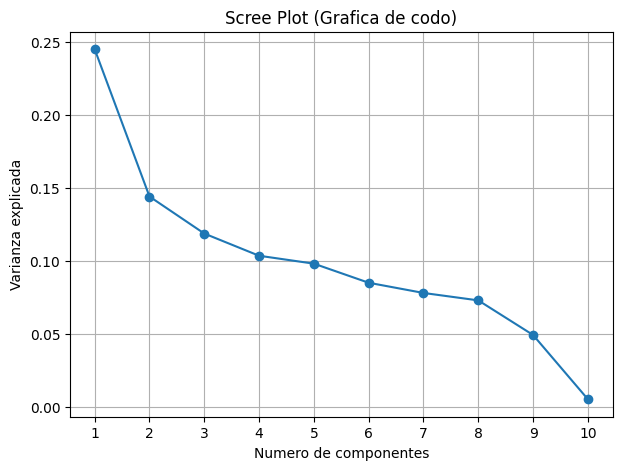

Varianza por componente: [0.24514598 0.14413946 0.1187557  0.10353164 0.09811119 0.08501611
 0.07801821 0.0729256  0.04920671 0.00514941]
Varianza acumulada: [0.24514598 0.38928544 0.50804114 0.61157277 0.70968396 0.79470007
 0.87271828 0.94564388 0.99485059 1.        ]


In [33]:
pca_full = PCA()
pca_full.fit(x_scaled)
plt.figure(figsize=(7,5))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) +1),
    pca_full.explained_variance_ratio_,
    marker = 'o'
)
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) +1))
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Grafica de codo)")
plt.grid(True)
plt.show()
print("Varianza por componente:", pca_full.explained_variance_ratio_)
print("Varianza acumulada:", pca_full.explained_variance_ratio_.cumsum())

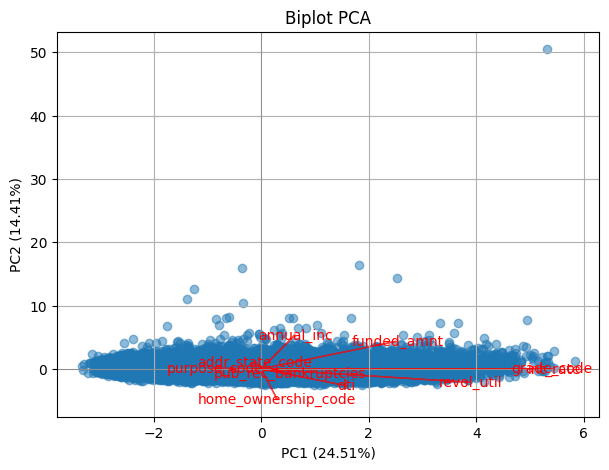

In [41]:
pca = PCA(n_components=6) #definimos el pca con 6 componentes
components = pca.fit_transform(x_scaled) #calcular pca
#componentes
PC1 = components[:,0]
PC2 = components[:,1]
PC3 = components[:,2]
PC4 = components[:,3]
PC5 = components[:,4]
PC6 = components[:,5]
loadings = pca.components_.T #Loadings vectores
variables = x.columns #Guarda los nombres de las variables originales.
plt.figure(figsize=(7,5))
#Graficar puntos (scores)
plt.scatter(PC1, PC2, alpha=0.5)
# Etiquetas de ejes
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
#Graficar vectores (loadings)
for i, var in enumerate(variables):
  plt.arrow(0,0,
            loadings[i,0]*9, #Multiplicador para mejorar visualizacion
            loadings[i,1]*9,
            color='red',
            alpha=0.7,
            head_width=0.05)
  plt.text(loadings[i,0]*9.2,
           loadings[i,1]*9.2,
           var, color='red', ha='center', va='center')
plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

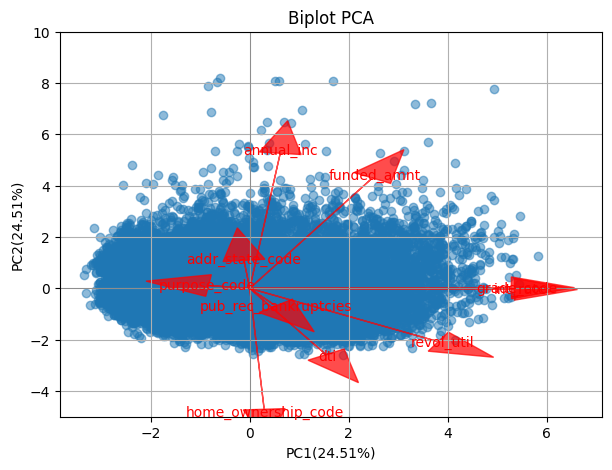

In [45]:
pca = PCA(n_components=6)
components = pca.fit_transform(x_scaled)
PC1 = components[:,0]
PC2 = components[:,1]
PC3 = components[:,2]
PC4 = components[:,3]
PC5 = components[:,4]
PC6 = components[:,5]
loadings = pca.components_.T
variables = x.columns
plt.figure(figsize=(7,5))
plt.scatter(PC1, PC2, alpha=0.5)
plt.xlabel(f"PC1({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylim(-5,10)# Ajustar
#Graficar vectores (loadings)
for i, var in enumerate(variables):
  plt.arrow(0,0,
            loadings[i,0]*9,
            loadings[i,1]*9,
            color='red',
            alpha=0.7,
            head_width=0.85)
  plt.text(loadings[i,0]*9.2,
           loadings[i,1]*9.2,
           var, color='red', ha='center', va='center')
plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

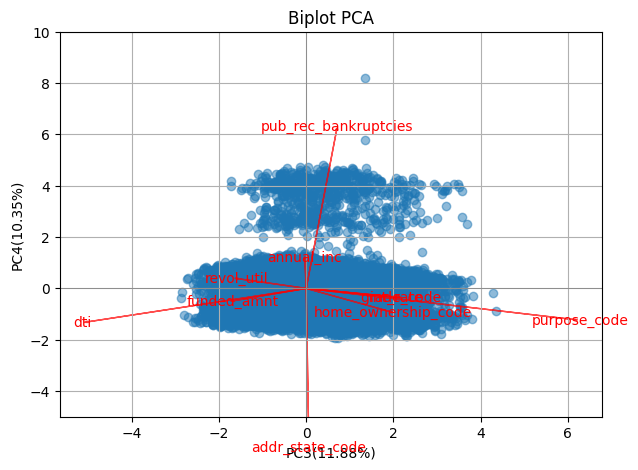

In [54]:
pca = PCA(n_components=6)
components = pca.fit_transform(x_scaled)
PC1 = components[:,0]
PC2 = components[:,1]
PC3 = components[:,2]
PC4 = components[:,3]
PC5 = components[:,4]
PC6 = components[:,5]
loadings = pca.components_.T
variables = x.columns
plt.figure(figsize=(7,5))
plt.scatter(PC3, PC4, alpha=0.5)
plt.xlabel(f"PC3({pca.explained_variance_ratio_[2]*100:.2f}%)")
plt.ylabel(f"PC4({pca.explained_variance_ratio_[3]*100:.2f}%)")
plt.ylim(-5, 10)
for i, var in enumerate (variables):
  plt.arrow(0, 0,
            loadings[i,2]*9,
            loadings[i,3]*9,
            color='red',
            alpha=0.7,
            head_width=0.05)
  plt.text(loadings[i,2]*9.2,
           loadings[i,3]*9.2,
           var, color='red', ha='center', va='center')
plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()